In [201]:
import numpy as np

In [202]:
def f(x):
    return 0.5 * np.exp(-np.abs(x))

In [203]:
def random_walk_metropolis(N, s, X):
    for i in range(1, N+1):
        x_star = np.random.normal(X[i-1], s)
        log_r = np.log(f(x_star)) - np.log(f(X[i-1]))
        u = np.random.uniform(0, 1)

        if np.log(u) < log_r:
            X.append(x_star)
        else:
            X.append(X[i-1])

    return X

In [204]:
# 1a
N = 10000
s = 5
X = [2]

X = random_walk_metropolis(N, s, X)

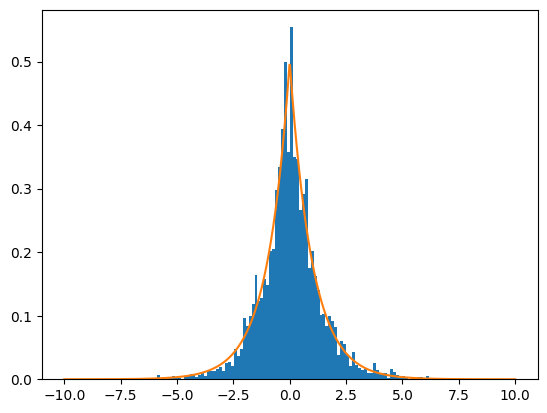

In [205]:
import matplotlib.pyplot as plt
plt.hist(X, bins=100, density=True)
x = np.linspace(-10, 10, 1000)
plt.plot(x, f(x))
plt.show()



In [206]:
print('Sample mean:', np.mean(X))
print('Sample standard deviation:', np.std(X))





Sample mean: 0.03920569539238854
Sample standard deviation: 1.3971550102271173


In [207]:
# 1b
J = 4
N = 2000
s = 1

X = {}
X["J1"] = [2]
X["J2"] = [8]
X["J3"] = [5]
X["J4"] = [1]

X

{'J1': [2], 'J2': [8], 'J3': [5], 'J4': [1]}

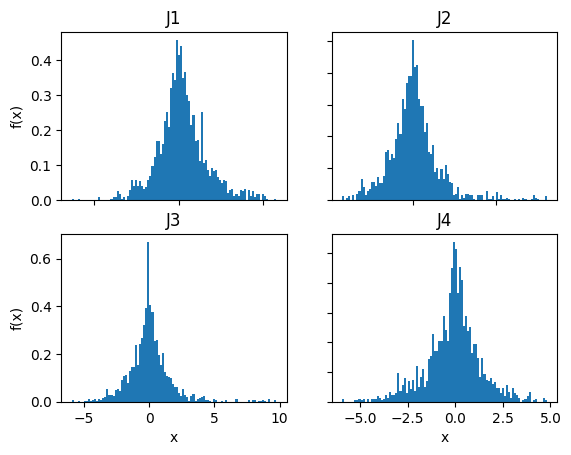

In [208]:
for xs in X:
    X[xs] = random_walk_metropolis(N, s, X[xs])

# plot the histogram
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2)
axs[0, 0].hist(X["J1"], bins=100, density=True)
axs[0, 0].set_title('J1')
axs[0, 1].hist(X["J2"], bins=100, density=True)
axs[0, 1].set_title('J2')
axs[1, 0].hist(X["J3"], bins=100, density=True)
axs[1, 0].set_title('J3')
axs[1, 1].hist(X["J4"], bins=100, density=True)
axs[1, 1].set_title('J4')



for ax in axs.flat:
    ax.set(xlabel='x', ylabel='f(x)')
    ax.label_outer()
    
plt.show()


In [209]:
def calculate_r_hat(X):
    M = {}
    for xs in X:
        M[xs] = np.mean(X[xs])
    V = {}
    for xs in X:
        V[xs] = np.var(X[xs])
        
    W = 1/J * np.sum([V[xs] for xs in X])
    M_bar = np.mean([M[xs] for xs in X])
    B = 1/J * np.sum([(M[xs] - M_bar)**2 for xs in X])
    R_hat = np.sqrt((B+W)/W)
    return R_hat

print("R_hat: ", calculate_r_hat(X))

R_hat:  1.0027710012905227


(100,)


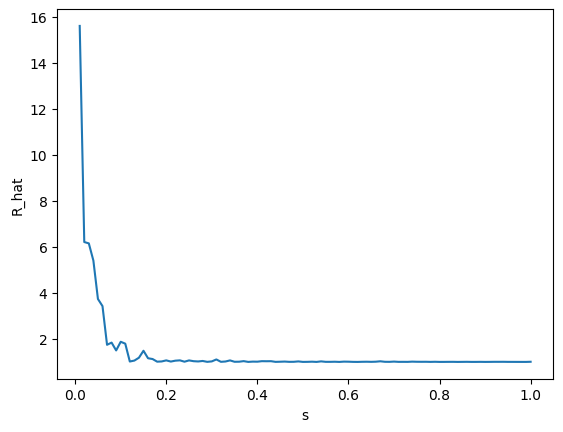

In [210]:
s_values = np.linspace(0.01, 1, 100)
R_hat_values = []

for s in s_values:
    X = {}
    X["J1"] = [2]
    X["J2"] = [8]
    X["J3"] = [5]
    X["J4"] = [1]
    for xs in X:
        X[xs] = random_walk_metropolis(N, s, X[xs])
    R_hat_values.append(calculate_r_hat(X))

plt.plot(s_values, R_hat_values)
plt.xlabel('s')
plt.ylabel('R_hat')
plt.show()
